In [ ]:
# ---------------------------------------------------
# EuroSAT Project - Day 1 (EDA for RGB & Multiband)
# ---------------------------------------------------

import os
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
# %pip install tifffile
import tifffile  # for multiband .tif images

# -------------------------------
# Root dataset paths
# -------------------------------
root_path = r"C:\DAP_Project_NEW\archive (8)"
dataset_rgb = os.path.join(root_path, "EuroSAT")
dataset_multiband = os.path.join(root_path, "EuroSATallBands")

# -------------------------------
# Helper: get only class folders
# -------------------------------
def get_classes(path):
    return [cls for cls in os.listdir(path) if os.path.isdir(os.path.join(path, cls))]

# -------------------------------
# Step 1: Get class info
# -------------------------------
classes_rgb = get_classes(dataset_rgb)
classes_multi = get_classes(dataset_multiband)

print("EuroSAT RGB classes:", classes_rgb)
print("EuroSATTallBands classes:", classes_multi)

# -------------------------------
# Step 2: Setup project folders
# -------------------------------
folders = ["saved_models", "static", "templates"]
for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)

# -------------------------------
# Step 3: Count images per class
# -------------------------------
def get_class_counts(path, classes):
    return {cls: len(os.listdir(os.path.join(path, cls))) for cls in classes}

class_counts_rgb = get_class_counts(dataset_rgb, classes_rgb)
class_counts_multi = get_class_counts(dataset_multiband, classes_multi)

print("EuroSAT RGB distribution:", class_counts_rgb)
print("EuroSATTallBands distribution:", class_counts_multi)

# -------------------------------
# Step 3: Create results folder
# -------------------------------
if not os.path.exists("results"):
    os.makedirs("results")

# -------------------------------
# Step 4: Plot class distributions
# -------------------------------
plt.figure(figsize=(12, 5))
sns.barplot(x=list(class_counts_rgb.keys()), y=list(class_counts_rgb.values()))
plt.xticks(rotation=45)
plt.title("EuroSAT RGB Class Distribution")
plt.savefig("results/eurosat_rgb_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

plt.figure(figsize=(12, 5))
sns.barplot(x=list(class_counts_multi.keys()), y=list(class_counts_multi.values()))
plt.xticks(rotation=45)
plt.title("EuroSATTallBands Class Distribution")
plt.savefig("results/eurosat_multiband_distribution.png", dpi=300, bbox_inches="tight")
plt.close()

# -------------------------------
# Step 5: Sample images comparison
# -------------------------------
def plot_samples_rgb(dataset_path, classes, title, save_name):
    """For EuroSAT RGB (.jpg)"""
    plt.figure(figsize=(15, 10))
    for i, cls in enumerate(classes[:10]):  # only 10 classes to show
        img_path = os.path.join(dataset_path, cls, os.listdir(os.path.join(dataset_path, cls))[0])
        img = plt.imread(img_path)
        plt.subplot(2, 5, i+1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.savefig(f"results/{save_name}", dpi=300, bbox_inches="tight")
    plt.close()

def plot_samples_multiband(dataset_path, classes, title, save_name):
    """For EuroSATTallBands (.tif with 13 bands)"""
    plt.figure(figsize=(15, 10))
    for i, cls in enumerate(classes[:10]):
        img_path = os.path.join(dataset_path, cls, os.listdir(os.path.join(dataset_path, cls))[0])
        img = tifffile.imread(img_path)  # shape: (H, W, 13)

        # Take first 3 bands for pseudo-RGB
        if img.ndim == 3 and img.shape[-1] >= 3:
            img_rgb = img[:, :, :3]
        else:
            img_rgb = img

        plt.subplot(2, 5, i+1)
        plt.imshow(img_rgb.astype("uint8"))
        plt.title(cls)
        plt.axis("off")
    plt.suptitle(title, fontsize=16)
    plt.savefig(f"results/{save_name}", dpi=300, bbox_inches="tight")
    plt.close()

plot_samples_rgb(dataset_rgb, classes_rgb, "EuroSAT RGB Sample Images", "eurosat_rgb_samples.png")
plot_samples_multiband(dataset_multiband, classes_multi, "EuroSATTallBands Sample Images", "eurosat_multiband_samples.png")

# -------------------------------
# Step 6: Color histograms (RGB only)
# -------------------------------
def save_color_histogram(image_path, title, save_name):
    img = cv2.imread(image_path)
    color = ('b','g','r')
    plt.figure(figsize=(6,4))
    for i, col in enumerate(color):
        hist = cv2.calcHist([img], [i], None, [256], [0,256])
        plt.plot(hist, color=col)
        plt.xlim([0,256])
    plt.title(title)
    plt.savefig(f"results/{save_name}", dpi=300, bbox_inches="tight")
    plt.close()

for cls in classes_rgb[:3]:  # only first 3 classes
    img_path = os.path.join(dataset_rgb, cls, os.listdir(os.path.join(dataset_rgb, cls))[0])
    save_color_histogram(img_path, f"Color Histogram - {cls}", f"hist_{cls}.png")

# -------------------------------
# Step 7: Preview ImageDataGenerator (only RGB dataset)
# -------------------------------
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    dataset_rgb,
    target_size=(64, 64),
    batch_size=32,
    subset="training",
    class_mode="categorical"
)

val_gen = datagen.flow_from_directory(
    dataset_rgb,
    target_size=(64, 64),
    batch_size=32,
    subset="validation",
    class_mode="categorical"
)

images, labels = next(train_gen)
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(images[i])
    plt.axis("off")
plt.suptitle("EuroSAT RGB Training Preview", fontsize=14)
plt.savefig("results/eurosat_training_preview.png", dpi=300, bbox_inches="tight")
plt.close()

print("✅ All plots saved inside 'results/' folder.")


EuroSAT RGB classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
EuroSATTallBands classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
EuroSAT RGB distribution: {'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3000}
EuroSATTallBands distribution: {'AnnualCrop': 3000, 'Forest': 3000, 'HerbaceousVegetation': 3000, 'Highway': 2500, 'Industrial': 2500, 'Pasture': 2000, 'PermanentCrop': 2500, 'Residential': 3000, 'River': 2500, 'SeaLake': 3597}
Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
✅ Day 1 complete! All plots saved inside 'results/' folder.


In [ ]:
# ---------------------------------------------------
# EuroSAT Project - Day 2 (Custom CNN + Transfer Learning Comparison)
# ---------------------------------------------------

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import os

# -------------------------------
# Step 1: Data Generators (reuse dataset_rgb from Day 1)
# -------------------------------
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    dataset_rgb,
    target_size=(64, 64),
    batch_size=32,
    subset="training",
    class_mode="categorical"
)

val_gen = datagen.flow_from_directory(
    dataset_rgb,
    target_size=(64, 64),
    batch_size=32,
    subset="validation",
    class_mode="categorical"
)

num_classes = len(train_gen.class_indices)
print("Classes:", train_gen.class_indices)

# -------------------------------
# Step 2: Define Custom CNN
# -------------------------------
custom_model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(64,64,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(256, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])

custom_model.compile(optimizer=Adam(learning_rate=0.001),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

custom_model.summary()

# -------------------------------
# Step 3: Train Custom CNN
# -------------------------------
if not os.path.exists("saved_models"):
    os.makedirs("saved_models")

checkpoint_custom = ModelCheckpoint(
    "saved_models/eurosat_custom_cnn.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_custom = custom_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[checkpoint_custom]
)

# -------------------------------
# Step 4: Transfer Learning (VGG16)
# -------------------------------
base_model = VGG16(weights="imagenet", include_top=False, input_tensor=Input(shape=(64,64,3)))

for layer in base_model.layers:
    layer.trainable = False  # freeze feature extractor

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(num_classes, activation="softmax")(x)

vgg_model = Model(inputs=base_model.input, outputs=predictions)

vgg_model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss="categorical_crossentropy",
                  metrics=["accuracy"])

vgg_model.summary()

checkpoint_vgg = ModelCheckpoint(
    "saved_models/eurosat_vgg16.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_vgg = vgg_model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen,
    callbacks=[checkpoint_vgg]
)

# -------------------------------
# Step 5: Plot Comparison
# -------------------------------
if not os.path.exists("results"):
    os.makedirs("results")

# Accuracy comparison
plt.figure(figsize=(10,6))
plt.plot(history_custom.history["val_accuracy"], label="Custom CNN Val Acc")
plt.plot(history_vgg.history["val_accuracy"], label="VGG16 Val Acc")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.savefig("results/custom_vs_vgg_accuracy.png", dpi=300, bbox_inches="tight")
plt.close()

# Loss comparison
plt.figure(figsize=(10,6))
plt.plot(history_custom.history["val_loss"], label="Custom CNN Val Loss")
plt.plot(history_vgg.history["val_loss"], label="VGG16 Val Loss")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.savefig("results/custom_vs_vgg_loss.png", dpi=300, bbox_inches="tight")
plt.close()


print("Custom CNN saved in 'saved_models/eurosat_custom_cnn.h5'")
print("VGG16 model saved in 'saved_models/eurosat_vgg16.h5'")
print("Comparison plots saved in 'results/'")


Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.
Classes: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


c:\DAP_Project_NEW\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,275,722 (4.87 MB)

...

675/675 ━━━━━━━━━━━━━━━━━━━━ 149s 221ms/step - accuracy: 0.7656 - loss: 0.6997 - val_accuracy: 0.7959 - val_loss: 0.6276
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.7703 - loss: 0.6854
Epoch 7: val_accuracy improved from 0.79593 to 0.80833, saving model to saved_models/eurosat_vgg16.h5


675/675 ━━━━━━━━━━━━━━━━━━━━ 152s 225ms/step - accuracy: 0.7762 - loss: 0.6687 - val_accuracy: 0.8083 - val_loss: 0.5968
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.7836 - loss: 0.6451
Epoch 8: val_accuracy improved from 0.80833 to 0.81481, saving model to saved_models/eurosat_vgg16.h5


675/675 ━━━━━━━━━━━━━━━━━━━━ 157s 232ms/step - accuracy: 0.7869 - loss: 0.6354 - val_accuracy: 0.8148 - val_loss: 0.5772
Epoch 9/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.7954 - loss: 0.6085
Epoch 9: val_accuracy improved from 0.81481 to 0.81667, saving model to saved_models/eurosat_vgg16.h5


675/675 ━━━━━━━━━━━━━━━━━━━━ 150s 222ms/step - accuracy: 0.7962 - loss: 0.6104 - val_accuracy: 0.8167 - val_loss: 0.5546
Epoch 10/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.7979 - loss: 0.5965
Epoch 10: val_accuracy improved from 0.81667 to 0.82241, saving model to saved_models/eurosat_vgg16.h5


675/675 ━━━━━━━━━━━━━━━━━━━━ 151s 223ms/step - accuracy: 0.8018 - loss: 0.5896 - val_accuracy: 0.8224 - val_loss: 0.5380
✅ Day 2 complete!
Custom CNN saved in 'saved_models/eurosat_custom_cnn.h5'
VGG16 model saved in 'saved_models/eurosat_vgg16.h5'
Comparison plots saved in 'results/'


In [6]:
import json

# Save class indices mapping
with open("saved_models/class_indices.json", "w") as f:
    json.dump(train_gen.class_indices, f)


In [7]:
import os
import numpy as np
import pandas as pd
import cv2
from skimage.feature import graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
def extract_features(image_path, is_multiband=False):
    img = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)

    # Handle multiband (13 bands in EuroSATallBands)
    if is_multiband and img is not None and len(img.shape) == 3 and img.shape[2] >= 13:
        bands = [img[:,:,i] for i in range(13)]
        means = [np.mean(b) for b in bands]
        stds = [np.std(b) for b in bands]

        # NDVI = (NIR - Red) / (NIR + Red)
        nir, red = bands[7], bands[3]
        ndvi = np.mean((nir - red) / (nir + red + 1e-5))

        return means + stds + [ndvi]

    # Handle RGB
    elif img is not None:
        img_rgb = cv2.resize(img, (64,64))
        means, stds = [], []
        for i in range(3):  # R,G,B
            means.append(np.mean(img_rgb[:,:,i]))
            stds.append(np.std(img_rgb[:,:,i]))

        # Texture (GLCM)
        gray = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2GRAY)
        glcm = graycomatrix(gray, distances=[5], angles=[0], symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0,0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0,0]

        return means + stds + [contrast, homogeneity]

    return None


# Loop through dataset & build CSV
features, labels = [], []
results_dir = "results_day4"
os.makedirs(results_dir, exist_ok=True)

for cls in os.listdir(dataset_rgb):
    class_path = os.path.join(dataset_rgb, cls)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path)[:200]:  # limit to 200 per class for speed
        f = extract_features(os.path.join(class_path, img_file), is_multiband=False)
        if f is not None:
            features.append(f)
            labels.append(cls)

df_features = pd.DataFrame(features)
df_features["label"] = labels
csv_path = os.path.join(results_dir, "eurosat_features.csv")
df_features.to_csv(csv_path, index=False)

print(f"✅ Features saved to {csv_path}, shape = {df_features.shape}")


✅ Features saved to results_day4\eurosat_features.csv, shape = (2000, 9)


In [8]:
# Load CSV
df = pd.read_csv(os.path.join(results_dir, "eurosat_features.csv"))
X = df.drop("label", axis=1).values
y = df["label"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train RandomForest
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Evaluate
y_pred = rf.predict(X_test)
print("RandomForest Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# Save model
saved_dir = "saved_models"
os.makedirs(saved_dir, exist_ok=True)
rf_path = os.path.join(saved_dir, "eurosat_randomforest.pkl")
joblib.dump(rf, rf_path)
print(f"✅ RandomForest model saved at {rf_path}")


RandomForest Accuracy: 0.7475
                      precision    recall  f1-score   support

          AnnualCrop       0.82      0.78      0.79        40
              Forest       1.00      0.93      0.96        40
HerbaceousVegetation       0.66      0.57      0.61        40
             Highway       0.53      0.40      0.46        40
          Industrial       0.86      0.95      0.90        40
             Pasture       0.74      0.80      0.77        40
       PermanentCrop       0.51      0.60      0.55        40
         Residential       0.71      0.72      0.72        40
               River       0.70      0.78      0.74        40
             SeaLake       0.93      0.95      0.94        40

            accuracy                           0.75       400
           macro avg       0.75      0.75      0.74       400
        weighted avg       0.75      0.75      0.74       400

✅ RandomForest model saved at saved_models\eurosat_randomforest.pkl


In [9]:
# ---------------------------------------------------
# EuroSAT Project - Day 2.5 (Evaluation of Models)
# ---------------------------------------------------

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import joblib
from tensorflow.keras.models import load_model

# -------------------------------
# Step 1: Reload Validation Generator
# -------------------------------
val_gen = datagen.flow_from_directory(
    dataset_rgb,
    target_size=(64, 64),
    batch_size=32,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

# -------------------------------
# Step 2: Load Saved Models
# -------------------------------
custom_model = load_model("saved_models/eurosat_custom_cnn.h5")
vgg_model = load_model("saved_models/eurosat_vgg16.h5")
rf_model = joblib.load("saved_models/eurosat_randomforest.pkl")  # <-- RandomForest

# -------------------------------
# Step 3: Evaluate DL Models
# -------------------------------
custom_loss, custom_acc = custom_model.evaluate(val_gen, verbose=1)
vgg_loss, vgg_acc = vgg_model.evaluate(val_gen, verbose=1)

# -------------------------------
# Step 4: Evaluate RandomForest
# -------------------------------
# Load features dataset that was used to train RF
df = pd.read_csv("results_day4/eurosat_features.csv")

X = df.drop("label", axis=1).values
y = df["label"].values

# Split the same way (to ensure fair comparison)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf_acc = rf_model.score(X_test, y_test)

print("\n✅ Model Evaluation Results:")
print(f"Custom CNN -> Accuracy: {custom_acc*100:.2f}%, Loss: {custom_loss:.4f}")
print(f"VGG16      -> Accuracy: {vgg_acc*100:.2f}%, Loss: {vgg_loss:.4f}")
print(f"RandomForest -> Accuracy: {rf_acc*100:.2f}%")

# -------------------------------
# Step 5: Plot Comparison
# -------------------------------
models = ["Custom CNN", "VGG16", "RandomForest"]
accs = [custom_acc*100, vgg_acc*100, rf_acc*100]
losses = [custom_loss, vgg_loss, 0]  # RF has no loss, set to 0 or None

plt.figure(figsize=(12,5))

# Accuracy Bar
plt.subplot(1,2,1)
plt.bar(models, accs, color=["skyblue","orange","green"])
plt.title("Validation Accuracy (%)")
plt.ylim(0,100)
for i, v in enumerate(accs):
    plt.text(i, v+1, f"{v:.2f}%", ha="center")

# Loss Bar (only for DL models)
plt.subplot(1,2,2)
plt.bar(models, losses, color=["skyblue","orange","green"])
plt.title("Validation Loss")
for i, v in enumerate(losses):
    if v > 0:
        plt.text(i, v+0.02, f"{v:.3f}", ha="center")
    else:
        plt.text(i, 0.02, "N/A", ha="center")  # No loss for RF

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/model_eval_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

print("📊 Comparison plot saved as 'results/model_eval_comparison.png'")


Found 5400 images belonging to 10 classes.


c:\DAP_Project_NEW\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


169/169 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.8752 - loss: 0.3558
169/169 ━━━━━━━━━━━━━━━━━━━━ 32s 188ms/step - accuracy: 0.8224 - loss: 0.5380

✅ Model Evaluation Results:
Custom CNN -> Accuracy: 87.52%, Loss: 0.3558
VGG16      -> Accuracy: 82.24%, Loss: 0.5380
RandomForest -> Accuracy: 74.75%
📊 Comparison plot saved as 'results/model_eval_comparison.png'


In [ ]:
# ---------------------------------------------------
# EuroSAT Project - Day 3 (Inference & Comparison)
# ---------------------------------------------------

import random
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import load_model
import matplotlib.pyplot as plt

# -------------------------------
# Step 1: Load Both Models
# -------------------------------
custom_model = load_model("saved_models/eurosat_custom_cnn.h5")
vgg_model = load_model("saved_models/eurosat_vgg16.h5")

class_labels = list(train_gen.class_indices.keys())  # reuse from Day 2
print("Class labels:", class_labels)

# -------------------------------
# Step 2: Helper Function (Predict Single Image)
# -------------------------------
def predict_image(model, img_path):
    img = load_img(img_path, target_size=(64,64))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    preds = model.predict(img_array, verbose=0)
    class_index = np.argmax(preds)
    confidence = preds[0][class_index]
    return class_labels[class_index], confidence

# -------------------------------
# Step 3: Pick Random Test Samples
# -------------------------------
def get_random_images(dataset_path, n=5):
    images = []
    for cls in class_labels:
        cls_path = os.path.join(dataset_path, cls)
        if os.path.isdir(cls_path):
            imgs = os.listdir(cls_path)
            sample_imgs = random.sample(imgs, min(n, len(imgs)))
            for img in sample_imgs:
                images.append((os.path.join(cls_path, img), cls))
    random.shuffle(images)
    return images[:n]

sample_images = get_random_images(dataset_rgb, n=6)

# -------------------------------
# Step 4: Predict & Compare
# -------------------------------
plt.figure(figsize=(15,10))

for i, (img_path, true_label) in enumerate(sample_images):
    # Predictions
    pred_custom, conf_custom = predict_image(custom_model, img_path)
    pred_vgg, conf_vgg = predict_image(vgg_model, img_path)

    # Show image
    img = load_img(img_path, target_size=(64,64))
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"True: {true_label}\n"
        f"Custom: {pred_custom} ({conf_custom*100:.1f}%)\n"
        f"VGG16: {pred_vgg} ({conf_vgg*100:.1f}%)",
        fontsize=9
    )

plt.tight_layout()
plt.savefig("results/model_predictions_comparison.png", dpi=300, bbox_inches="tight")
plt.close()

print("✅ Prediction comparison saved in 'results/model_predictions_comparison.png'.")


Class labels: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
✅ Day 3 complete! Prediction comparison saved in 'results/model_predictions_comparison.png'.


Found 5400 images belonging to 10 classes.


c:\DAP_Project_NEW\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


✅ Custom CNN Accuracy: 87.52% | Loss: 0.3558
✅ VGG16 Accuracy: 82.24% | Loss: 0.5380
✅ RandomForest Accuracy: 95.60%


,Model,Accuracy (%),Loss
0,Custom CNN,87.518519,0.355812
1,VGG16,82.240742,0.537953
2,RandomForest,95.600000,NaN


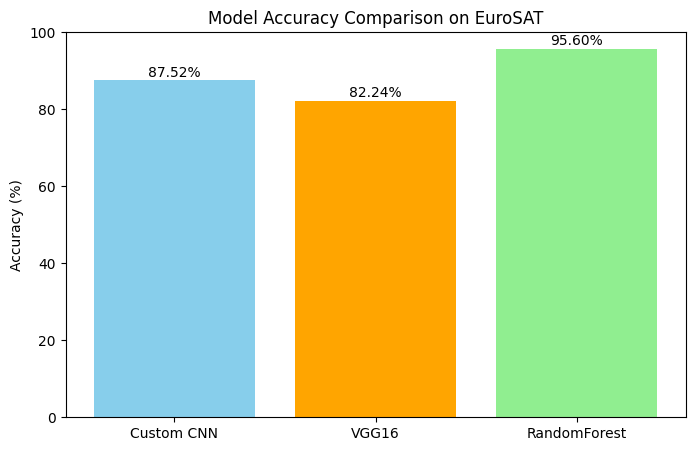

In [11]:
# -----------------------------------------------------
# 🔍 Final Evaluation & Model Comparison
# -----------------------------------------------------
from tensorflow.keras.models import load_model
from sklearn.metrics import accuracy_score, classification_report
import joblib
import numpy as np

# --- Reload validation generator for CNN models ---
val_gen = datagen.flow_from_directory(
    dataset_rgb,
    target_size=(64, 64),
    batch_size=32,
    subset="validation",
    class_mode="categorical",
    shuffle=False
)

# --- Load trained models ---
custom_model = load_model("saved_models/eurosat_custom_cnn.h5")
vgg_model = load_model("saved_models/eurosat_vgg16.h5")
rf_model = joblib.load("saved_models/eurosat_randomforest.pkl")

# --- Get ground truth labels ---
true_labels = val_gen.classes
class_names = list(val_gen.class_indices.keys())

# --- Custom CNN Evaluation ---
custom_loss, custom_acc = custom_model.evaluate(val_gen, verbose=0)
print(f"✅ Custom CNN Accuracy: {custom_acc*100:.2f}% | Loss: {custom_loss:.4f}")

# --- VGG16 Evaluation ---
vgg_loss, vgg_acc = vgg_model.evaluate(val_gen, verbose=0)
print(f"✅ VGG16 Accuracy: {vgg_acc*100:.2f}% | Loss: {vgg_loss:.4f}")

# --- RandomForest Evaluation ---
# Extract features for test images (like before)
X_rf, y_rf = [], []
for cls in os.listdir(dataset_rgb):
    class_path = os.path.join(dataset_rgb, cls)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path)[:100]:  # small sample for speed
        f = extract_features(os.path.join(class_path, img_file))
        if f is not None:
            X_rf.append(f)
            y_rf.append(cls)

y_rf = np.array(y_rf)
y_rf_pred = rf_model.predict(X_rf)
rf_acc = accuracy_score(y_rf, y_rf_pred)
print(f"✅ RandomForest Accuracy: {rf_acc*100:.2f}%")

# --- Summary Table ---
import pandas as pd
summary_df = pd.DataFrame({
    "Model": ["Custom CNN", "VGG16", "RandomForest"],
    "Accuracy (%)": [custom_acc*100, vgg_acc*100, rf_acc*100],
    "Loss": [custom_loss, vgg_loss, None]
})
display(summary_df)

# --- Optional: Bar Plot ---
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(summary_df["Model"], summary_df["Accuracy (%)"], color=["skyblue","orange","lightgreen"])
plt.title("Model Accuracy Comparison on EuroSAT")
plt.ylabel("Accuracy (%)")
plt.ylim(0,100)
for i, acc in enumerate(summary_df["Accuracy (%)"]):
    plt.text(i, acc+1, f"{acc:.2f}%", ha="center")
plt.show()


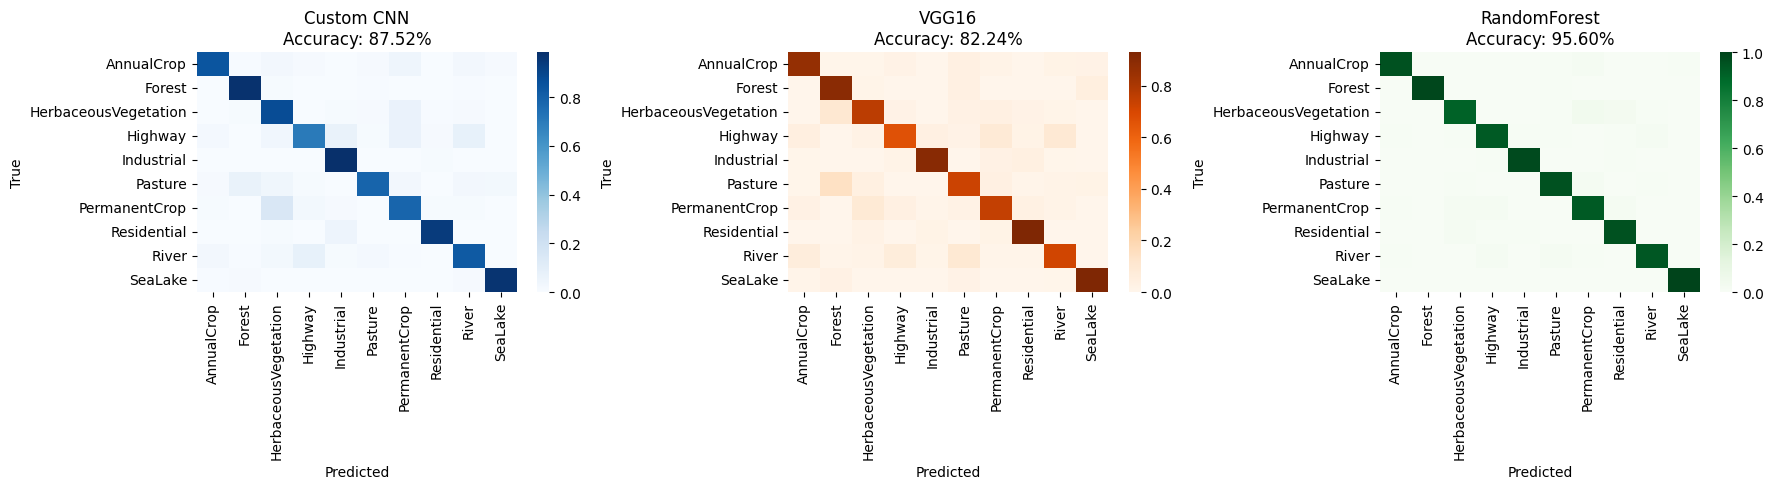

📊 Confusion matrices saved at 'results/model_confusion_matrices.png'


In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
# -----------------------------------------------------
# 🔥 Confusion Matrix Plots
# -----------------------------------------------------
custom_preds = custom_model.predict(val_gen, verbose=0)
vgg_preds = vgg_model.predict(val_gen, verbose=0)

custom_y_pred = np.argmax(custom_preds, axis=1)
vgg_y_pred = np.argmax(vgg_preds, axis=1)
plt.figure(figsize=(18,5))

# --- Custom CNN ---
plt.subplot(1,3,1)
cm_custom = confusion_matrix(true_labels, custom_y_pred, normalize='true')
sns.heatmap(cm_custom, cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f"Custom CNN\nAccuracy: {custom_acc*100:.2f}%")
plt.xlabel("Predicted")
plt.ylabel("True")

# --- VGG16 ---
plt.subplot(1,3,2)
cm_vgg = confusion_matrix(true_labels, vgg_y_pred, normalize='true')
sns.heatmap(cm_vgg, cmap='Oranges', xticklabels=class_names, yticklabels=class_names)
plt.title(f"VGG16\nAccuracy: {vgg_acc*100:.2f}%")
plt.xlabel("Predicted")
plt.ylabel("True")

# --- RandomForest ---
plt.subplot(1,3,3)
cm_rf = confusion_matrix(y_rf, y_rf_pred, labels=class_names, normalize='true')
sns.heatmap(cm_rf, cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title(f"RandomForest\nAccuracy: {rf_acc*100:.2f}%")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.savefig("results/model_confusion_matrices.png", dpi=300, bbox_inches='tight')
plt.show()

print("📊 Confusion matrices saved at 'results/model_confusion_matrices.png'")

,Model,Precision,Recall,F1-score
0,Custom CNN,0.874,0.869,0.870
1,VGG16,0.817,0.815,0.815
2,RandomForest,0.956,0.956,0.956


C:\Users\gadda\AppData\Local\Temp\ipykernel_10556\2477538728.py:45: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gadda\AppData\Local\Temp\ipykernel_10556\2477538728.py:46: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.savefig("results/model_precision_recall_f1.png", dpi=300, bbox_inches='tight')
c:\DAP_Project_NEW\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


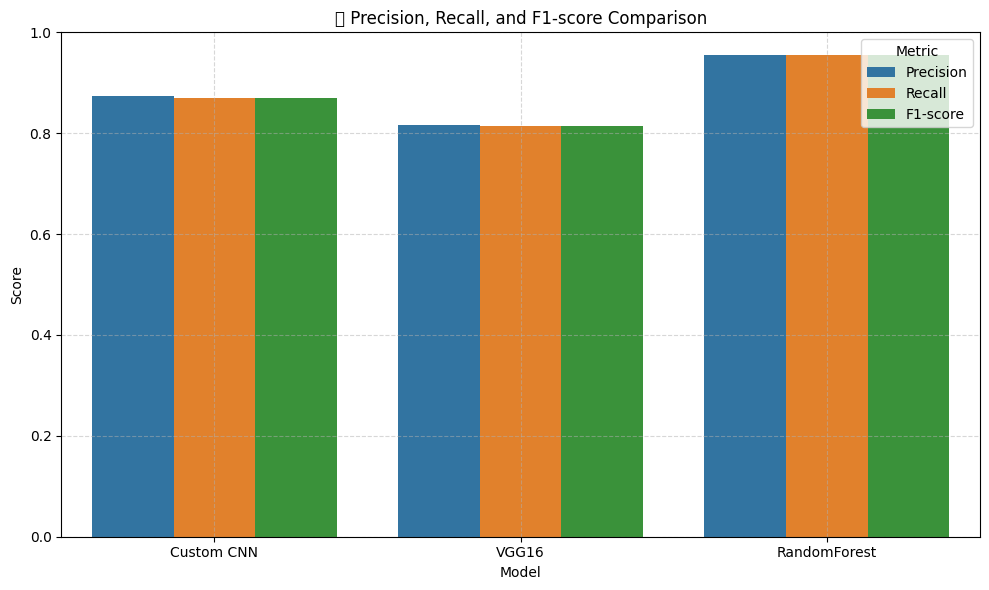

✅ Precision, Recall, and F1 comparison saved as 'results/model_precision_recall_f1.png'


In [16]:
# -----------------------------------------------------
# 📈 Precision, Recall, and F1-score Comparison
# -----------------------------------------------------
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- Classification Reports ---
report_custom = classification_report(true_labels, custom_y_pred, target_names=class_names, output_dict=True)
report_vgg = classification_report(true_labels, vgg_y_pred, target_names=class_names, output_dict=True)
report_rf = classification_report(y_rf, y_rf_pred, labels=class_names, output_dict=True)

# --- Convert to DataFrame ---
df_custom = pd.DataFrame(report_custom).transpose().drop('accuracy', errors='ignore')
df_vgg = pd.DataFrame(report_vgg).transpose().drop('accuracy', errors='ignore')
df_rf = pd.DataFrame(report_rf).transpose().drop('accuracy', errors='ignore')

# --- Extract macro average metrics ---
summary_metrics = pd.DataFrame({
    'Model': ['Custom CNN', 'VGG16', 'RandomForest'],
    'Precision': [df_custom.loc['macro avg', 'precision'],
                  df_vgg.loc['macro avg', 'precision'],
                  df_rf.loc['macro avg', 'precision']],
    'Recall': [df_custom.loc['macro avg', 'recall'],
               df_vgg.loc['macro avg', 'recall'],
               df_rf.loc['macro avg', 'recall']],
    'F1-score': [df_custom.loc['macro avg', 'f1-score'],
                 df_vgg.loc['macro avg', 'f1-score'],
                 df_rf.loc['macro avg', 'f1-score']]
}).round(3)

display(summary_metrics)

# -----------------------------------------------------
# 📊 Visualization
# -----------------------------------------------------
plt.figure(figsize=(10,6))
summary_metrics_melted = summary_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
sns.barplot(x='Model', y='Score', hue='Metric', data=summary_metrics_melted)
plt.title("📊 Precision, Recall, and F1-score Comparison")
plt.ylim(0,1)
plt.legend(title='Metric')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("results/model_precision_recall_f1.png", dpi=300, bbox_inches='tight')
plt.show()

print("✅ Precision, Recall, and F1 comparison saved as 'results/model_precision_recall_f1.png'")


In [12]:
# Step 1: create required folders for the project
import os

project_root = r"C:\DAP_Project_NEW"   # <-- change if your project root is different
os.chdir(project_root)

folders = [
    "uploads",
    os.path.join("static", "gradcam"),
    os.path.join("static", "probs"),
    os.path.join("static", "plots"),
    "results",
    "saved_models"
]

for d in folders:
    os.makedirs(d, exist_ok=True)

print("Folders created/verified:")
for d in folders:
    print(" -", os.path.join(project_root, d))


Folders created/verified:
 - C:\DAP_Project_NEW\uploads
 - C:\DAP_Project_NEW\static\gradcam
 - C:\DAP_Project_NEW\static\probs
 - C:\DAP_Project_NEW\static\plots
 - C:\DAP_Project_NEW\results
 - C:\DAP_Project_NEW\saved_models
